Author(s) : Daniel R., Tarry, Laura Gómez-Navarro, Elisabet Verger-Miralles, Lara Diaz-Barroso

Objective: Describe xxx

Created on: October 2023

Last updated on:


In [1]:
import time

print(time.ctime(time.time()))

Wed Jun 12 16:33:15 2024


In [2]:
import sys
sys.path.insert(0, "../../processing/")

In [3]:
import numpy as np
import xarray as xr # version 0.20.1 necesarry, 0.16 gives error when calculating u_for
import matplotlib.pyplot as plt
import scipy.signal as signal

import cartopy
import cartopy.crs as ccrs
import cartopy.feature       as cfeature
from cartopy.mpl.gridliner import LongitudeFormatter, LatitudeFormatter

from read_data_tools import latlon2uv_dir

In [4]:
# version_information

In [5]:
print(xr.__version__)

2023.6.0


# Parameters:

In [6]:
url_drifter = "drifter_carthe006-ime_carthe001/L0/2023/dep0002_drifter-carthe006_ime-carthe001_L0_2023-04-26.nc?"
drifter_type = 'C' # C: CARTHE ; H: Hereon ; S: SVP-B 

# n_window = 12 # we leave like this for now

# Drifter example

# 1. Loading the data:

In [7]:
# Main root
url_root = "http://thredds.socib.es/thredds/dodsC/drifter/surface_drifter/"

In [8]:
# parameters of the thredd file

if drifter_type == 'C':
    url_vars = "trajectory,time[0:1:-1],DEPTH,LAT[0:1:-1],LON[0:1:-1],BAT_STATUS[0:1:-1]"
    temp_res = 600. # Specifying seconds 
    # Step depending on drifter (CARTHE and HEREON 600s (10 mins (we choose the highest time resolution)) 
    savestr = 'CARTHE'
elif drifter_type == 'H':
    url_vars = "trajectory,time[0:1:-1],LAT[0:1:-1],LON[0:1:-1],DEPTH,BAT_STATUS[0:1:-1]"
    temp_res = 600. # Specifying seconds 
    # Step depending on drifter (CARTHE and HEREON 600s (10 mins (we choose the highest time resolution)) 
    savestr = 'HEREON'
elif drifter_type == 'S':
    url_vars = "trajectory,time[0:1:-1],DEPTH,WTEM[0:1:-1],VOLT[0:1:-1],LAT[0:1:-1],DROGUE[0:1:-1],LON[0:1:-1],APRE[0:1:-1]"
    temp_res = 3600. # Specifying seconds 
    savestr = 'SVPB'
else:
    print('add option, SVP missing temp , press , BAT_status different')
    fsdfs

In [9]:
# Load file

url = url_root + url_drifter + url_vars
 
print(url)

ds00 = xr.open_dataset(url)


http://thredds.socib.es/thredds/dodsC/drifter/surface_drifter/drifter_carthe006-ime_carthe001/L0/2023/dep0002_drifter-carthe006_ime-carthe001_L0_2023-04-26.nc?trajectory,time[0:1:-1],DEPTH,LAT[0:1:-1],LON[0:1:-1],BAT_STATUS[0:1:-1]


In [10]:
ds00

<xarray.Dataset>
Dimensions:     (time: 4255)
Coordinates:
  * time        (time) datetime64[ns] 2023-04-26T10:16:51 ... 2023-05-28T19:1...
    DEPTH       float64 ...
    LAT         (time) float64 ...
    LON         (time) float64 ...
Data variables:
    trajectory  |S64 ...
    BAT_STATUS  (time) float64 ...
Attributes: (12/67)
    title:                               Data from instrument IME-CARTHE001 o...
    institution:                         IMEDEA (Instituto MEDiterráneo de Es...
    netcdf_version:                      3.0
    Conventions:                         CF-1.6
    abstract:                            Deployment of IME-CARTHE001 in FaSt-...
    summary:                             Deployment of IME-CARTHE001 in FaSt-...
    ...                                  ...
    citation:                            Balearic Island Coastal and Observin...
    acknowledgement:                     The FaSt-SWOT project is funded by t...
    update_interval:                     every 3600 seconds
    DODS.strlen:                         34
    DODS.dimName:                        name_strlen
    DODS_EXTRA.Unlimited_Dimension:      time

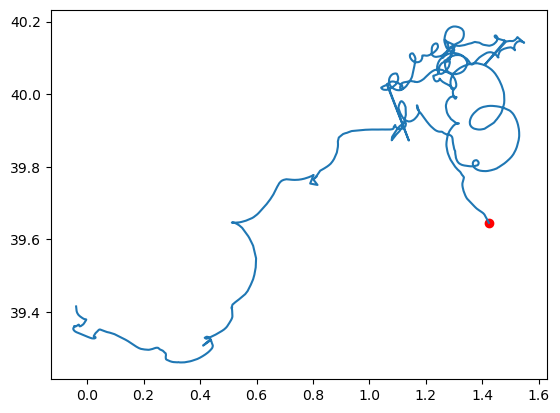

In [11]:

plt.plot(ds00.LON, ds00.LAT)
plt.scatter(ds00.LON[0], ds00.LAT[0], c='r')

# Saving L0:

In [12]:
rootdir = '/Users/Gomez023/Postdoc/data/'
savedir = rootdir + 'FaST-SWOT/drifters/' + savestr + '/L0_SOCIB/'

In [14]:
ds00.to_netcdf(savedir + savestr + '_' + ds00.instrument_serial[2::] + '.nc')